In [ ]:
import pandas as pd

# Archived exploration. The reusable parts now live in covidbench/; see README.
# Path is relative to Notebooks/.
df = pd.read_csv("../corona_tested_individuals_ver_006.english.csv")
print(df.shape)
print(df.head())


(278848, 10)
    test_date  cough  fever  sore_throat  shortness_of_breath  head_ache  \
0  2020-04-30    0.0    0.0          0.0                  0.0        0.0   
1  2020-04-30    1.0    0.0          0.0                  0.0        0.0   
2  2020-04-30    0.0    1.0          0.0                  0.0        0.0   
3  2020-04-30    1.0    0.0          0.0                  0.0        0.0   
4  2020-04-30    1.0    0.0          0.0                  0.0        0.0   

  corona_result age_60_and_above  gender test_indication  
0      negative              NaN  female           Other  
1      negative              NaN  female           Other  
2      negative              NaN    male           Other  
3      negative              NaN  female           Other  
4      negative              NaN    male           Other  


C:\Users\shuya.jia\AppData\Local\Temp\ipykernel_3956\3792785301.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv("corona_tested_individuals_ver_006.english.csv")


In [89]:
df.columns


Index(['test_date', 'cough', 'fever', 'sore_throat', 'shortness_of_breath',
       'head_ache', 'corona_result', 'age_60_and_above', 'gender',
       'test_indication'],
      dtype='object')

In [90]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278848 entries, 0 to 278847
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   test_date            278848 non-null  object 
 1   cough                278596 non-null  float64
 2   fever                278596 non-null  float64
 3   sore_throat          278847 non-null  float64
 4   shortness_of_breath  278847 non-null  float64
 5   head_ache            278847 non-null  float64
 6   corona_result        278848 non-null  object 
 7   age_60_and_above     151528 non-null  object 
 8   gender               259285 non-null  object 
 9   test_indication      278848 non-null  object 
dtypes: float64(5), object(5)
memory usage: 21.3+ MB


In [91]:
categorical_cols = [
    "corona_result",
    "age_60_and_above",
    "gender",
    "test_indication"
]

for col in categorical_cols:

    print(df[col].value_counts(dropna=False))
#corona results looks imbalanced


corona_result
negative    260227
positive     14729
other         3892
Name: count, dtype: int64
age_60_and_above
NaN    127320
No     125703
Yes     25825
Name: count, dtype: int64
gender
female    130158
male      129127
NaN        19563
Name: count, dtype: int64
test_indication
Other                     242741
Abroad                     25468
Contact with confirmed     10639
Name: count, dtype: int64


In [92]:
df["corona_result"].value_counts(normalize=True) * 100


corona_result
negative    93.322168
positive     5.282089
other        1.395742
Name: proportion, dtype: float64

In [93]:
df_binary = df[df["corona_result"].isin(["positive", "negative"])].copy()
df_binary.head()


,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
0,2020-04-30,0.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
1,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
2,2020-04-30,0.0,1.0,0.0,0.0,0.0,negative,NaN,male,Other
3,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
4,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,male,Other


In [94]:
df_binary["corona_result"].value_counts(normalize=True) * 100
#The target class was highly imbalanced, so accuracy alone would be inappropriate. 
# ROC-AUC, recall, precision and the confusion matrix provide more informative evaluation.


corona_result
negative    94.643143
positive     5.356857
Name: proportion, dtype: float64

In [95]:
df.isna().sum()
#missing values majority lies in age_60_and_above


test_date                   0
cough                     252
fever                     252
sore_throat                 1
shortness_of_breath         1
head_ache                   1
corona_result               0
age_60_and_above       127320
gender                  19563
test_indication             0
dtype: int64

In [96]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

missing_summary


,missing_count,missing_percent
age_60_and_above,127320,45.659284
gender,19563,7.015650
fever,252,0.090372
cough,252,0.090372
head_ache,1,0.000359
sore_throat,1,0.000359
shortness_of_breath,1,0.000359
test_date,0,0.000000
corona_result,0,0.000000
test_indication,0,0.000000


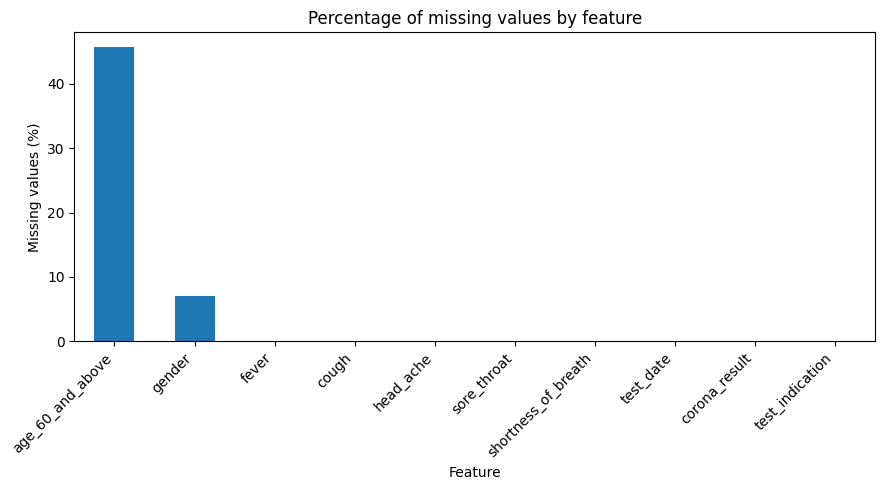

In [97]:
import matplotlib.pyplot as plt
missing_summary["missing_percent"].plot(kind="bar", figsize=(9, 5))
plt.ylabel("Missing values (%)")
plt.xlabel("Feature")
plt.title("Percentage of missing values by feature")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [98]:
symptoms = [
    "cough",
    "fever",
    "sore_throat",
    "shortness_of_breath",
    "head_ache"
]

for col in symptoms:

    print(df[col].value_counts(dropna=False))


cough
0.0    236368
1.0     42228
NaN       252
Name: count, dtype: int64
fever
0.0    256844
1.0     21752
NaN       252
Name: count, dtype: int64
sore_throat
0.0    276921
1.0      1926
NaN         1
Name: count, dtype: int64
shortness_of_breath
0.0    277270
1.0      1577
NaN         1
Name: count, dtype: int64
head_ache
0.0    276433
1.0      2414
NaN         1
Name: count, dtype: int64


In [99]:
print('min data')
print(df["test_date"].min())
print('max data')
print(df["test_date"].max())


min data
2020-03-11
max data
2020-04-30


In [100]:
symptom_by_class = (
    df_binary
    .groupby("corona_result")[symptoms]
    .mean()
    .T
)

symptom_by_class #bias on how the symptons recorded


corona_result,negative,positive
cough,0.134561,0.448013
fever,0.060829,0.378266
sore_throat,0.001406,0.103612
shortness_of_breath,0.001479,0.079033
head_ache,0.000569,0.151752


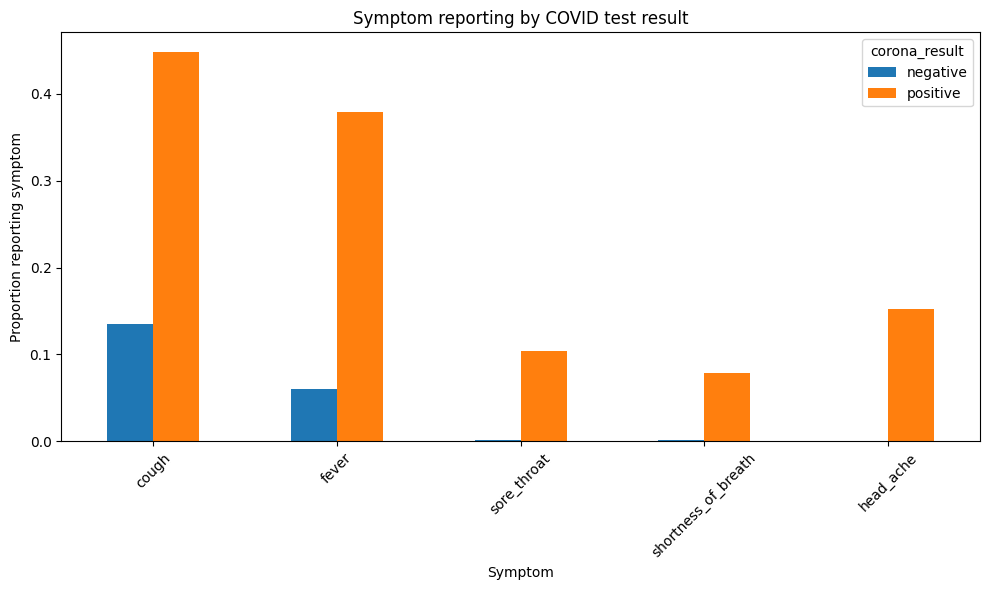

In [101]:
import matplotlib.pyplot as plt

symptom_by_class.plot(kind="bar", figsize=(10, 6))

plt.ylabel("Proportion reporting symptom")
plt.xlabel("Symptom")
plt.title("Symptom reporting by COVID test result")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


In [102]:
# Of people who reported each symptom, what percentage tested COVID-positive?
for symptom in symptoms:
    symptom_cases = df_binary[df_binary[symptom] == 1]  # keep people who reported this symptom

    positive_percentage = (
        symptom_cases["corona_result"]
        .eq("positive")
        .mean() * 100
    )

    print(symptom, round(positive_percentage, 2))
    #it seems that out of all of the symptons in reported cases, 
    # headache seem to be the largest one and tested positive
    #Of people recorded as having headache, about 94% were COVID-positive.


cough 15.84
fever 26.01
sore_throat 80.66
shortness_of_breath 75.15
head_ache 93.79


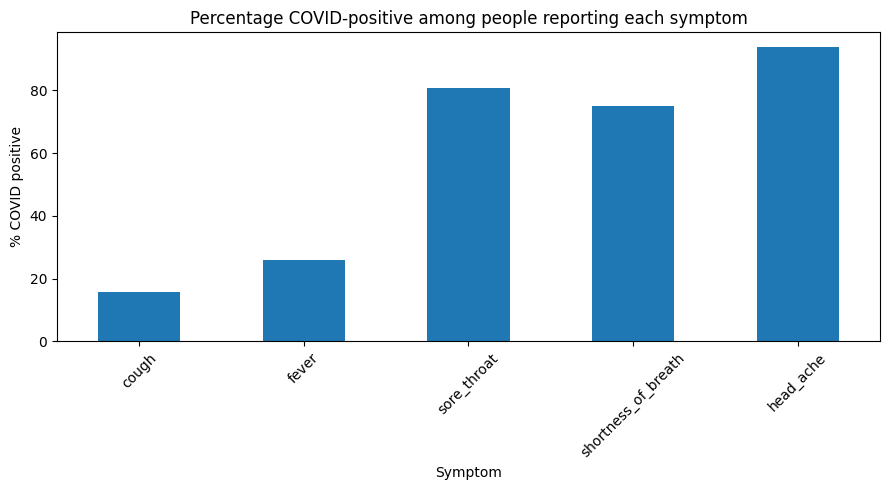

In [103]:
bias_results = {}

for symptom in symptoms:
    symptom_cases = df_binary[df_binary[symptom] == 1]

    bias_results[symptom] = (
        symptom_cases["corona_result"]
        .eq("positive")
        .mean() * 100
    )

bias_df = pd.Series(bias_results)

bias_df.plot(kind="bar", figsize=(9, 5))

plt.ylabel("% COVID positive")
plt.xlabel("Symptom")
plt.title("Percentage COVID-positive among people reporting each symptom")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


In [104]:
# Remove 'other' from the target so this becomes binary classification
df_model = df[df["corona_result"].isin(["positive", "negative"])].copy()

# Keep missing age as its own category
df_model["age_60_and_above"] = (
    df_model["age_60_and_above"]
    .fillna("Missing")
    .astype(str)
)

# Remove rows with missing values in categories/features where missingness is relatively small
small_missing_cols = [
    "cough",
    "fever",
    "sore_throat",
    "shortness_of_breath",
    "head_ache",
    "gender"
]

df_model = df_model.dropna(subset=small_missing_cols)

print("Rows after cleaning:", len(df_model))
print("\nTarget distribution:")
print(df_model["corona_result"].value_counts())
print("\nAge categories:")
print(df_model["age_60_and_above"].value_counts(dropna=False))


Rows after cleaning: 255668

Target distribution:
corona_result
negative    242136
positive     13532
Name: count, dtype: int64

Age categories:
age_60_and_above
Missing    119374
No         112593
Yes         23701
Name: count, dtype: int64


In [105]:
pd.crosstab(
    df_model["test_indication"],
    df_model["corona_result"],
    normalize="index"
) * 100
#Check whether `test_indication`, gender and age group are associated with the COVID result. 



corona_result,negative,positive
test_indication,,
Abroad,93.860740,6.139260
Contact with confirmed,28.750130,71.249870
Other,97.636085,2.363915


In [106]:
pd.crosstab(
    df_model["gender"],
    df_model["corona_result"],
    normalize="index"
) * 100
#male positive percentage is higher than female

corona_result,negative,positive
gender,,
female,95.308107,4.691893
male,94.100821,5.899179


In [107]:
pd.crosstab(
    df_model["age_60_and_above"],
    df_model["corona_result"],
    normalize="index"
) * 100


corona_result,negative,positive
age_60_and_above,,
Missing,97.565634,2.434366
No,92.385850,7.614150
Yes,91.337918,8.662082


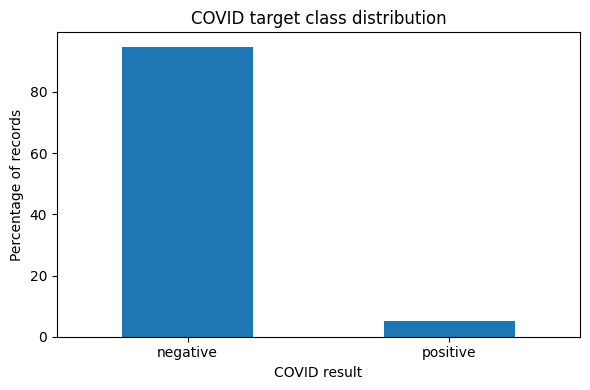

In [108]:
# Visualise target class imbalance
target_percent = df_model["corona_result"].value_counts(normalize=True) * 100

target_percent.plot(kind="bar", figsize=(6, 4))
plt.ylabel("Percentage of records")
plt.xlabel("COVID result")
plt.title("COVID target class distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [109]:
#`random_state=42`

#The first split is **70% training / 30% temporary data**.  
#The temporary 30% is then split equally into **15% validation / 15% test**.

from sklearn.model_selection import train_test_split

features = [
    "cough",
    "fever",
    "sore_throat",
    "shortness_of_breath",
    "head_ache",
    "age_60_and_above",
    "gender",
    "test_indication"
]

X = df_model[features].copy()
y = df_model["corona_result"].map({
    "negative": 0,
    "positive": 1
})#assigning neg and pos with values

# 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Split the temporary 30% equally -> 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", len(X_train), f"({len(X_train)/len(X):.1%})")
print("Validation:", len(X_val), f"({len(X_val)/len(X):.1%})")
print("Test:", len(X_test), f"({len(X_test)/len(X):.1%})")


Train: 178967 (70.0%)
Validation: 38350 (15.0%)
Test: 38351 (15.0%)


In [110]:
# Confirm that class proportions are similar in all three sets
split_check = pd.DataFrame({
    "train": y_train.value_counts(normalize=True),
    "validation": y_val.value_counts(normalize=True),
    "test": y_test.value_counts(normalize=True)
}).T

split_check.columns = ["negative", "positive"]
split_check * 100


,negative,positive
train,94.707404,5.292596
validation,94.706649,5.293351
test,94.706787,5.293213


In [111]:
# train_df = X_train.copy()
# train_df["target"] = y_train

# val_df = X_val.copy()
# val_df["target"] = y_val

# test_df = X_test.copy()
# test_df["target"] = y_test

In [112]:
# train_df.to_csv("train.csv", index=False)
# val_df.to_csv("validation.csv", index=False)
# test_df.to_csv("test.csv", index=False)

In [113]:
X_train = pd.get_dummies(X_train)

X_val = pd.get_dummies(X_val)
X_test = pd.get_dummies(X_test)

# Make sure the columns match
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [114]:
#RANDOM FOREST

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [115]:
from sklearn.metrics import roc_auc_score

y_val_prob = rf.predict_proba(X_val)[:, 1]

val_auc = roc_auc_score(y_val, y_val_prob)

print("Validation ROC-AUC:", val_auc)

Validation ROC-AUC: 0.9097161384301556


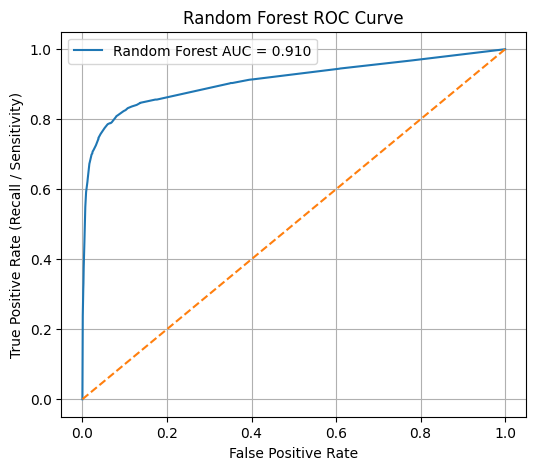

In [116]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get false positive rate, true positive rate and thresholds
fpr, tpr, thresholds = roc_curve(y_val, y_val_prob)

# Calculate AUC
val_auc = roc_auc_score(y_val, y_val_prob)

# Plot ROC curve
plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, label=f"Random Forest AUC = {val_auc:.3f}")

# Random guessing line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall / Sensitivity)")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.grid()

plt.show()

In [117]:
#Our Random Forest achieved a validation ROC-AUC of approximately 0.91, 
# which is comparable to the performance reported in the reference paper
#it separates positive and negative cases well

In [118]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

test_indication_Contact with confirmed    0.266501
test_indication_Other                     0.251114
fever                                     0.154881
cough                                     0.107418
head_ache                                 0.062404
age_60_and_above_Missing                  0.044529
test_indication_Abroad                    0.035828
sore_throat                               0.032461
shortness_of_breath                       0.020695
age_60_and_above_No                       0.010253
age_60_and_above_Yes                      0.006856
gender_male                               0.003702
gender_female                             0.003357
dtype: float64


In [119]:
#test indication contact with confirmed?

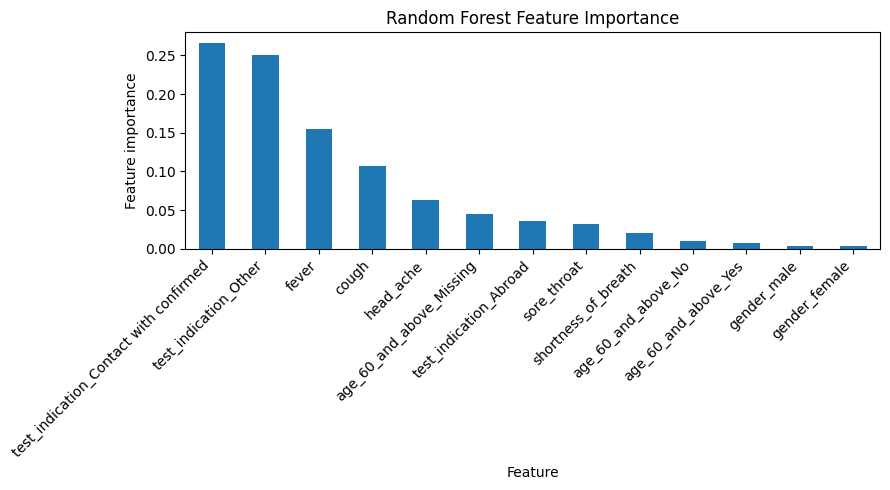

In [120]:
importance.plot(kind="bar", figsize=(9, 5))

plt.ylabel("Feature importance")
plt.xlabel("Feature")
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [121]:
#Random Forest is suitable for tabular classification data
# it can capture nonlinear relationships and interactions between symptoms
#  generally more robust than a single decision tree because it combines predictions from many trees.
#accuracy was not suitable
#The classes are strongly imbalanced
# accuracy could appear high even if the model missed most positive cases. 
# ROC-AUC gives a better measure of class separation
#It evaluates model discrimination across many classification thresholds rather than relying on one arbitrary threshold.

In [122]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
)

rf_baseline.fit(X_train, y_train)

y_val_prob_baseline = rf_baseline.predict_proba(X_val)[:, 1]
baseline_val_auc = roc_auc_score(y_val, y_val_prob_baseline)

print("Baseline validation ROC-AUC:", baseline_val_auc)
#baseline

Baseline validation ROC-AUC: 0.9098094252511881


In [123]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_leaf": [1, 5]
}

rf_tune = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

grid = GridSearchCV(
    estimator=rf_tune,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best cross-validation ROC-AUC:", grid.best_score_)
#hyperparameter


Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 200}
Best cross-validation ROC-AUC: 0.9076904373645337


In [124]:
best_rf = grid.best_estimator_

y_val_prob_tuned = best_rf.predict_proba(X_val)[:, 1]
tuned_val_auc = roc_auc_score(y_val, y_val_prob_tuned)

print("Tuned validation ROC-AUC:", tuned_val_auc)
print("Baseline validation ROC-AUC:", baseline_val_auc)
#best hyperparamerters from cross validation
#the tuned score is actually lower than the baseline because it is done via cross-validation on training data not according to the separate validation set
#however they are practically the same with little difference
#in conclusion:“Hyperparameter tuning did not materially improve ROC-AUC; the baseline and tuned models performed almost identically.


Tuned validation ROC-AUC: 0.9096798029556651
Baseline validation ROC-AUC: 0.9098094252511881


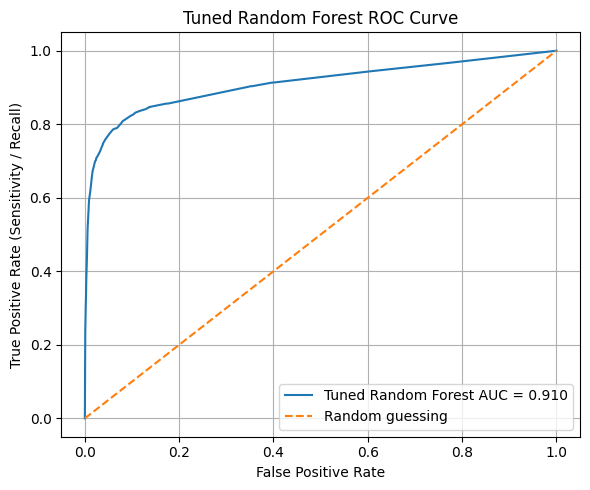

In [125]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_val, y_val_prob_tuned)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Tuned Random Forest AUC = {tuned_val_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random guessing")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity / Recall)")
plt.title("Tuned Random Forest ROC Curve")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()
#
# The y-axis is True Positive Rate (sensitivity/recall).  
# The x-axis is False Positive Rate.

# Each point on the ROC curve represents a different classification threshold.


test_indication_Contact with confirmed    0.271402
test_indication_Other                     0.253761
fever                                     0.150103
cough                                     0.102816
head_ache                                 0.062019
age_60_and_above_Missing                  0.040680
sore_throat                               0.035560
test_indication_Abroad                    0.034173
shortness_of_breath                       0.023017
age_60_and_above_No                       0.010763
age_60_and_above_Yes                      0.008488
gender_female                             0.003699
gender_male                               0.003520
dtype: float64


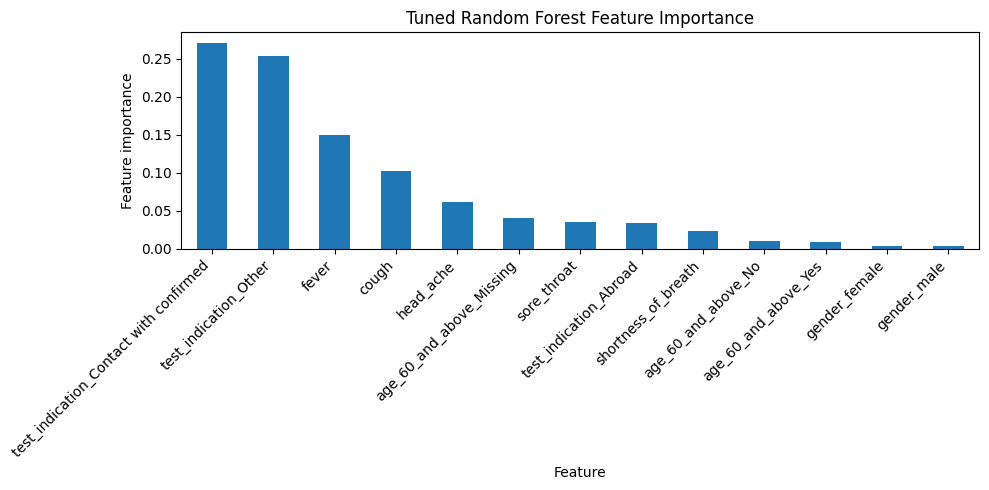

In [126]:
import pandas as pd

importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

importance.plot(kind="bar", figsize=(10, 5))
plt.ylabel("Feature importance")
plt.xlabel("Feature")
plt.title("Tuned Random Forest Feature Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [127]:
from sklearn.metrics import classification_report, confusion_matrix

y_val_pred = best_rf.predict(X_val)

print(classification_report(
    y_val,
    y_val_pred,
    target_names=["negative", "positive"]
))

tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred).ravel()

false_positive_rate = fp / (fp + tn)
false_negative_rate = fn / (fn + tp)

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)
print("False Positive Rate:", false_positive_rate)
print("False Negative Rate:", false_negative_rate)
print("False Positive Rate (%):", false_positive_rate * 100)
print("False Negative Rate (%):", false_negative_rate * 100)


              precision    recall  f1-score   support

    negative       0.99      0.93      0.96     36320
    positive       0.39      0.79      0.52      2030

    accuracy                           0.92     38350
   macro avg       0.69      0.86      0.74     38350
weighted avg       0.96      0.92      0.94     38350

True Negatives: 33803
False Positives: 2517
False Negatives: 424
True Positives: 1606
False Positive Rate: 0.06930066079295154
False Negative Rate: 0.20886699507389161
False Positive Rate (%): 6.930066079295154
False Negative Rate (%): 20.88669950738916


In [128]:
y_test_prob = best_rf.predict_proba(X_test)[:, 1] #using test data from ROC AUC
test_auc = roc_auc_score(y_test, y_test_prob)

print("Final test ROC-AUC:", test_auc)


Final test ROC-AUC: 0.9072258066178654


In [129]:
# Tuned validation ROC-AUC: 0.9096798029556651
# Baseline validation ROC-AUC: 0.9097161384301556
# Final test ROC-AUC: 0.9072258066178654